In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# ========================
# Output Directory Setup
# ========================
import datetime

# Create output directories
OUTPUT_BASE_DIR = './outputs'
REPORTS_DIR = os.path.join(OUTPUT_BASE_DIR, 'reports')
CHARTS_DIR = os.path.join(OUTPUT_BASE_DIR, 'charts')
RAW_DATA_DIR = os.path.join(OUTPUT_BASE_DIR, 'raw_data')

# Create directories if they don't exist
for directory in [OUTPUT_BASE_DIR, REPORTS_DIR, CHARTS_DIR, RAW_DATA_DIR]:
    os.makedirs(directory, exist_ok=True)

# Generate timestamp for this run
RUN_TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

print("✅ Output directories created:")
print(f"   Reports: {REPORTS_DIR}")
print(f"   Charts: {CHARTS_DIR}")
print(f"   Raw Data: {RAW_DATA_DIR}")
print(f"   Run timestamp: {RUN_TIMESTAMP}")

✅ Output directories created:
   Reports: ./outputs\reports
   Charts: ./outputs\charts
   Raw Data: ./outputs\raw_data
   Run timestamp: 20251209_195414


In [3]:
def collect_h5_file_paths(root_dir):
    file_paths = []
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('h5'):
                file_paths.append(os.path.join(dirpath, filename))

    return file_paths

In [4]:
ROOT_DIR = './data'
file_paths = collect_h5_file_paths(ROOT_DIR)

In [5]:
len(file_paths)

10000

In [6]:
def extract_features_from_h5(h5_file_path):
    """
    Extract song ID and 24-dimensional timbre feature vector (Mean/Std) from Million Song Dataset .h5 files.
    
    Args:
        h5_file_path (str): Full path to the HDF5 file.

    Returns:
        tuple (str, numpy.ndarray) or (None, None): 
        Contains (song_id, feature_vector) or (None, None).
    """
    try:
        with h5py.File(h5_file_path, 'r') as f:
            # Check if required groups exist
            if 'metadata' not in f or 'analysis' not in f:
                raise KeyError("Required groups 'metadata' or 'analysis' not found.")
            
            # 1. Extract song ID (from compound dataset 'songs')
            # Assuming 'songs' is the only compound dataset and 'song_id' is in it
            songs_metadata = f['metadata']['songs']
            # Extract 'song_id' field from first record and decode to Python string
            song_id = songs_metadata['song_id'][0].decode('utf-8')

            # 2. Extract segments_timbre matrix
            # This is the dataset located under 'analysis' group
            timbre = f['analysis']['segments_timbre'][:]
            
            # 3. Aggregate calculation (Mean and Std)
            # Timbre should have 12 dimensions. Calculate mean (12 dims) and std (12 dims) for each.
            timbre_mean = np.mean(timbre, axis=0)
            timbre_std = np.std(timbre, axis=0)
            
            if len(timbre_mean) != 12:
                 raise ValueError(f"Timbre dimension mismatch: expected 12, got {len(timbre_mean)}")

            # 4. Concatenate into single 24-dimensional feature vector
            feature_vector = np.concatenate([timbre_mean, timbre_std])
            
            return song_id, feature_vector

    except KeyError as ke:
        # Catch errors due to path errors or missing datasets/fields
        print(f"Skipping error processing {h5_file_path}: Key error: {ke}")
        return None, None
    except IndexError as ie:
        # Catch errors from attempting to index [0] on empty dataset
        print(f"Skipping error processing {h5_file_path}: Index error: {ie}")
        return None, None
    except Exception as e:
        # Catch all other exceptions
        print(f"Skipping error processing {h5_file_path}: General error: {e}")
        return None, None

In [7]:
all_song_data = {}

# Iterate through all files and extract data
print("Starting to scan files and extract features...")
for path in file_paths:
    song_id, features = extract_features_from_h5(path)
    
    if song_id:
        all_song_data[song_id] = features
print(f"Finished scanning. Total {len(all_song_data)} songs processed.")

Starting to scan files and extract features...
Finished scanning. Total 10000 songs processed.
Finished scanning. Total 10000 songs processed.


In [8]:
all_song_data

{'SOMZWCG12A8C13C480': array([ 41.51277755,  15.66293615,  -5.78968177,  -0.78984449,
        -43.23490319,  15.17094748,  15.13903811,   1.50500103,
          6.58957055,  12.2985551 , -13.56328012,   5.44247992,
          4.94454249,  61.51997339,  58.72095053,  54.4799564 ,
         32.52931687,  37.56815901,  27.00053439,  35.91573311,
         27.00545659,  24.12389234,  24.51061878,  17.7266023 ]),
 'SOCIWDW12A8C13D406': array([43.07103636, -4.03539091, 23.57229273, 12.92357636, -2.54503636,
         5.05239455,  9.23815091, -4.34597455,  5.22410364,  2.93566364,
        -2.75263818,  1.72939636,  5.84745467, 33.20336162, 28.86020588,
        39.90195041, 25.29130459, 29.12232911, 20.09004869, 19.60809283,
        17.55375405, 16.7973382 , 16.09334278, 12.0891049 ]),
 'SOXVLOJ12AB0189215': array([ 45.13081495, -76.82332562,  50.78732918,  13.50989324,
         -6.54925801,  -5.51424199,   1.88517794,  -8.96372954,
          3.75986299,  -5.11795374,   8.4420694 ,   4.47717082,
  

# Raw Data Analysis & Visualization

Comprehensive analysis of the original dataset before building the recommendation system.

In [9]:
# ========================
# Raw Data Statistics Report
# ========================

print("="*80)
print("📊 RAW DATA COMPREHENSIVE REPORT")
print("="*80)

# Basic statistics
total_songs = len(all_song_data)
total_features = len(list(all_song_data.values())[0]) if all_song_data else 0

print(f"\n📈 Dataset Overview:")
print(f"   Total Songs Loaded: {total_songs:,}")
print(f"   Feature Dimensions: {total_features} (12 timbre mean + 12 timbre std)")
print(f"   Total H5 Files Scanned: {len(file_paths):,}")
print(f"   Success Rate: {(total_songs/len(file_paths)*100):.2f}%")

# Feature statistics
print(f"\n📊 Feature Vector Statistics:")
feature_array = np.array(list(all_song_data.values()))

for i in range(12):
    print(f"\n   Timbre Dimension {i+1}:")
    print(f"      Mean:  min={feature_array[:, i].min():.4f}, max={feature_array[:, i].max():.4f}, avg={feature_array[:, i].mean():.4f}")
    print(f"      Std:   min={feature_array[:, i+12].min():.4f}, max={feature_array[:, i+12].max():.4f}, avg={feature_array[:, i+12].mean():.4f}")

# Data quality
print(f"\n✅ Data Quality Check:")
print(f"   NaN values: {np.isnan(feature_array).sum()}")
print(f"   Inf values: {np.isinf(feature_array).sum()}")
print(f"   Zero vectors: {(np.linalg.norm(feature_array, axis=1) == 0).sum()}")

# Sample songs
print(f"\n🎵 Sample Song IDs (first 10):")
for i, song_id in enumerate(list(all_song_data.keys())[:10], 1):
    print(f"   {i:2d}. {song_id}")

print("\n" + "="*80)

# Save raw data report
report_filename = os.path.join(REPORTS_DIR, f'raw_data_statistics_{RUN_TIMESTAMP}.txt')
with open(report_filename, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("RAW DATA COMPREHENSIVE REPORT\n")
    f.write("="*80 + "\n\n")
    f.write(f"Dataset Overview:\n")
    f.write(f"   Total Songs: {total_songs:,}\n")
    f.write(f"   Feature Dimensions: {total_features}\n")
    f.write(f"   H5 Files Scanned: {len(file_paths):,}\n")
    f.write(f"   Success Rate: {(total_songs/len(file_paths)*100):.2f}%\n\n")
    
    f.write(f"Feature Statistics:\n")
    for i in range(12):
        f.write(f"\nTimbre {i+1}:\n")
        f.write(f"  Mean:  min={feature_array[:, i].min():.4f}, max={feature_array[:, i].max():.4f}, avg={feature_array[:, i].mean():.4f}\n")
        f.write(f"  Std:   min={feature_array[:, i+12].min():.4f}, max={feature_array[:, i+12].max():.4f}, avg={feature_array[:, i+12].mean():.4f}\n")
    
    f.write(f"\nData Quality:\n")
    f.write(f"   NaN values: {np.isnan(feature_array).sum()}\n")
    f.write(f"   Inf values: {np.isinf(feature_array).sum()}\n")
    f.write(f"   Zero vectors: {(np.linalg.norm(feature_array, axis=1) == 0).sum()}\n")

print(f"\n✅ Report saved: {report_filename}")

📊 RAW DATA COMPREHENSIVE REPORT

📈 Dataset Overview:
   Total Songs Loaded: 10,000
   Feature Dimensions: 24 (12 timbre mean + 12 timbre std)
   Total H5 Files Scanned: 10,000
   Success Rate: 100.00%

📊 Feature Vector Statistics:

   Timbre Dimension 1:
      Mean:  min=4.5536, max=55.7061, avg=42.3917
      Std:   min=1.0562, max=15.1515, avg=5.4440

   Timbre Dimension 2:
      Mean:  min=-289.8626, max=217.7568, avg=-1.5021
      Std:   min=10.9072, max=175.9745, avg=47.0014

   Timbre Dimension 3:
      Mean:  min=-196.5536, max=308.5823, avg=12.5338
      Std:   min=13.1801, max=128.5460, avg=43.6564

   Timbre Dimension 4:
      Mean:  min=-85.1961, max=155.7372, avg=2.0833
      Std:   min=5.2704, max=163.9137, avg=39.0329

   Timbre Dimension 5:
      Mean:  min=-132.3456, max=128.8853, avg=-3.5938
      Std:   min=7.2368, max=106.1570, avg=30.0242

   Timbre Dimension 6:
      Mean:  min=-55.0865, max=94.5189, avg=-6.1516
      Std:   min=6.2039, max=89.8478, avg=29.3433

   

✅ Saved: 01_feature_mean_distribution


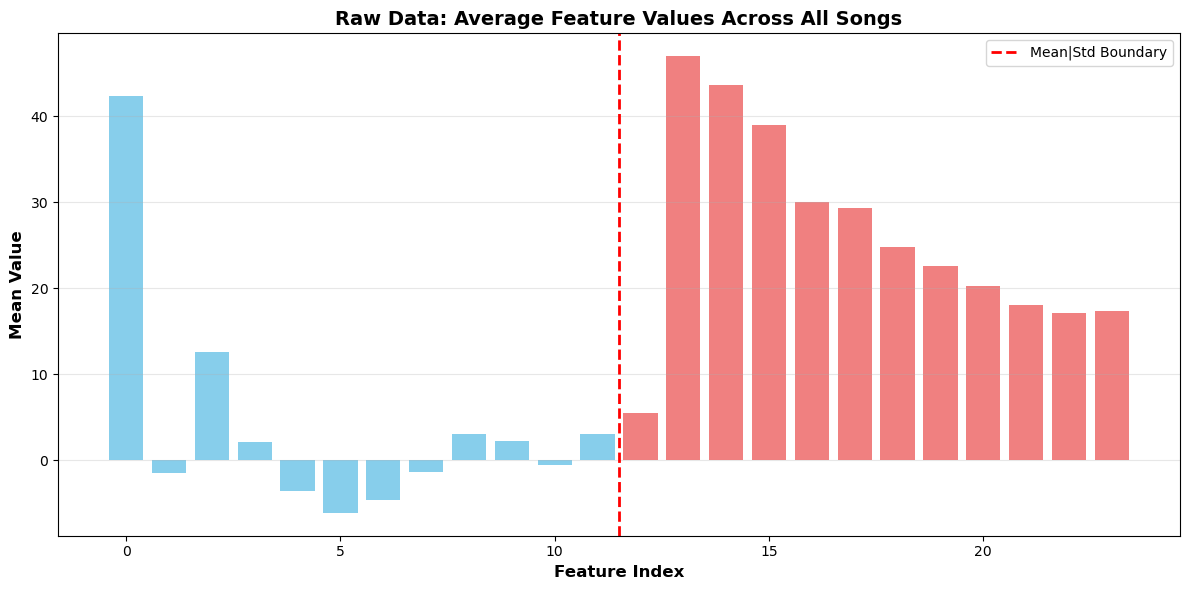

✅ Saved: 02_feature_std_distribution


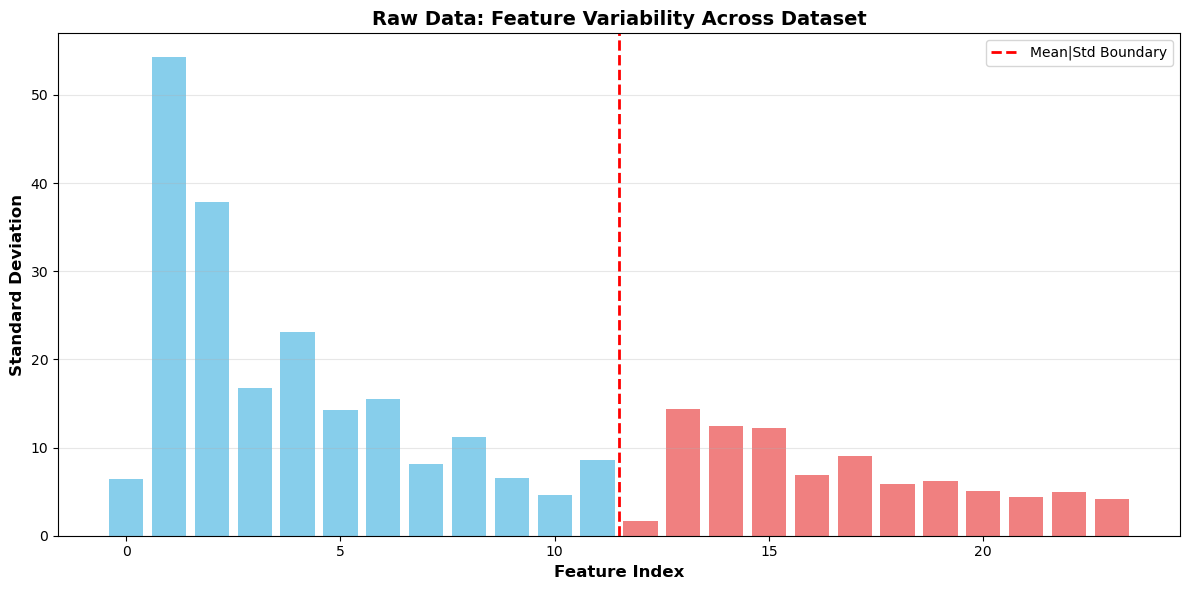

✅ Saved: 03_timbre_mean_heatmap


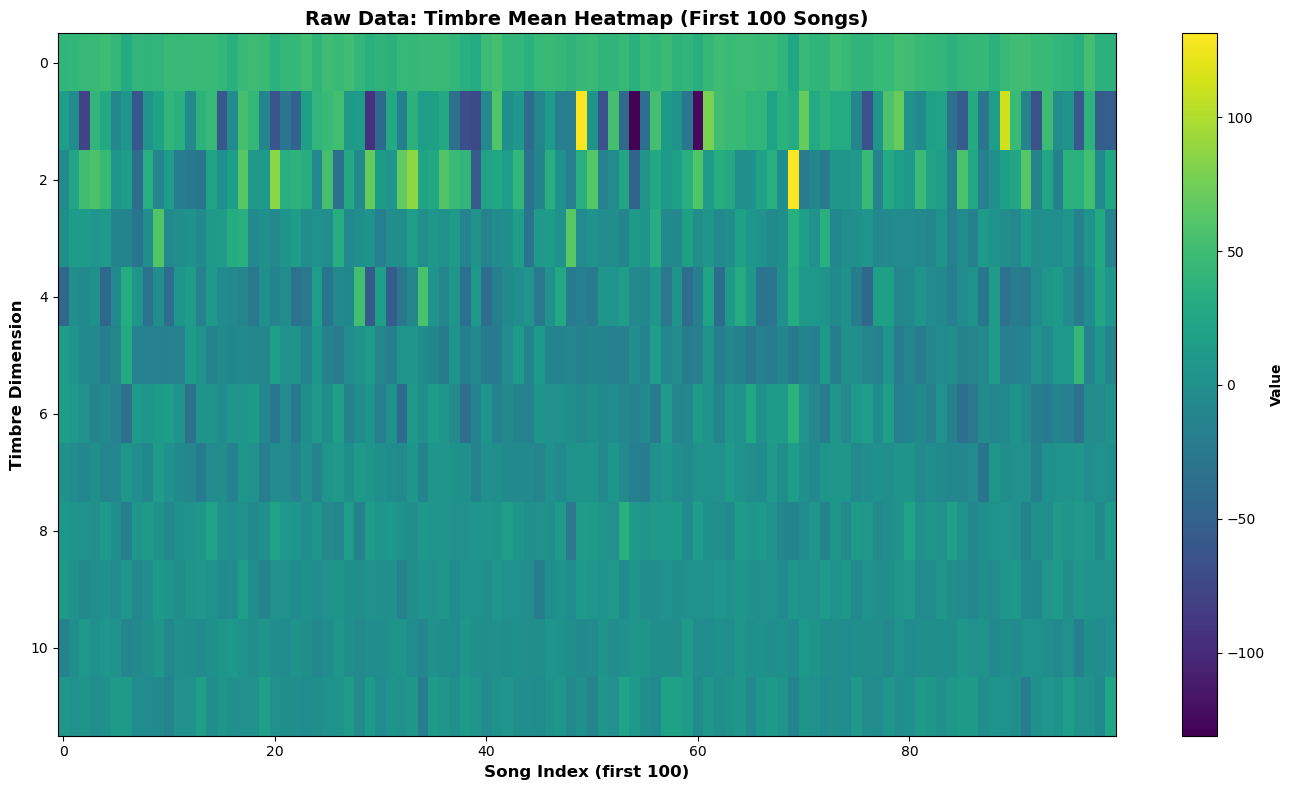

✅ Saved: 04_feature_correlation_matrix


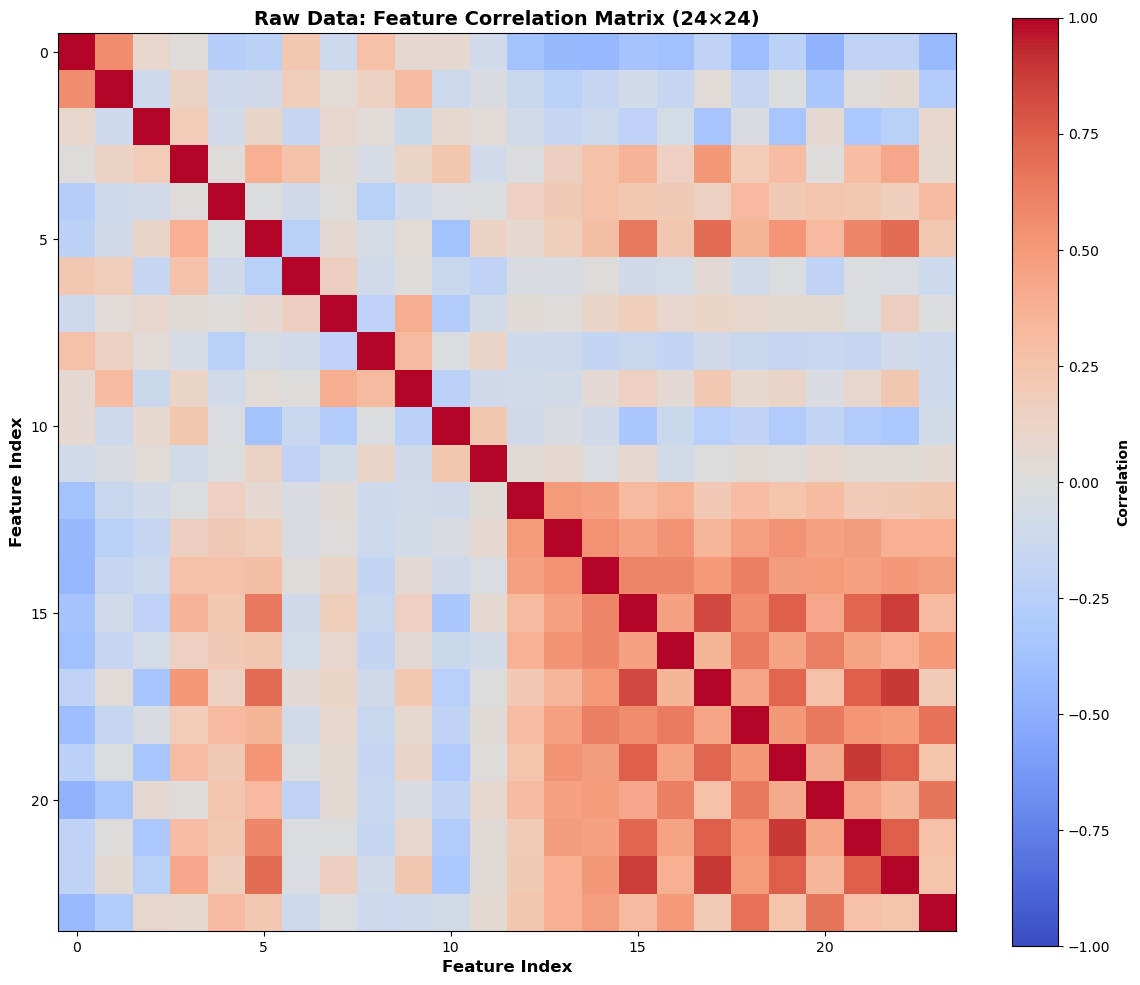

✅ Saved: 05_feature_distribution_boxplot


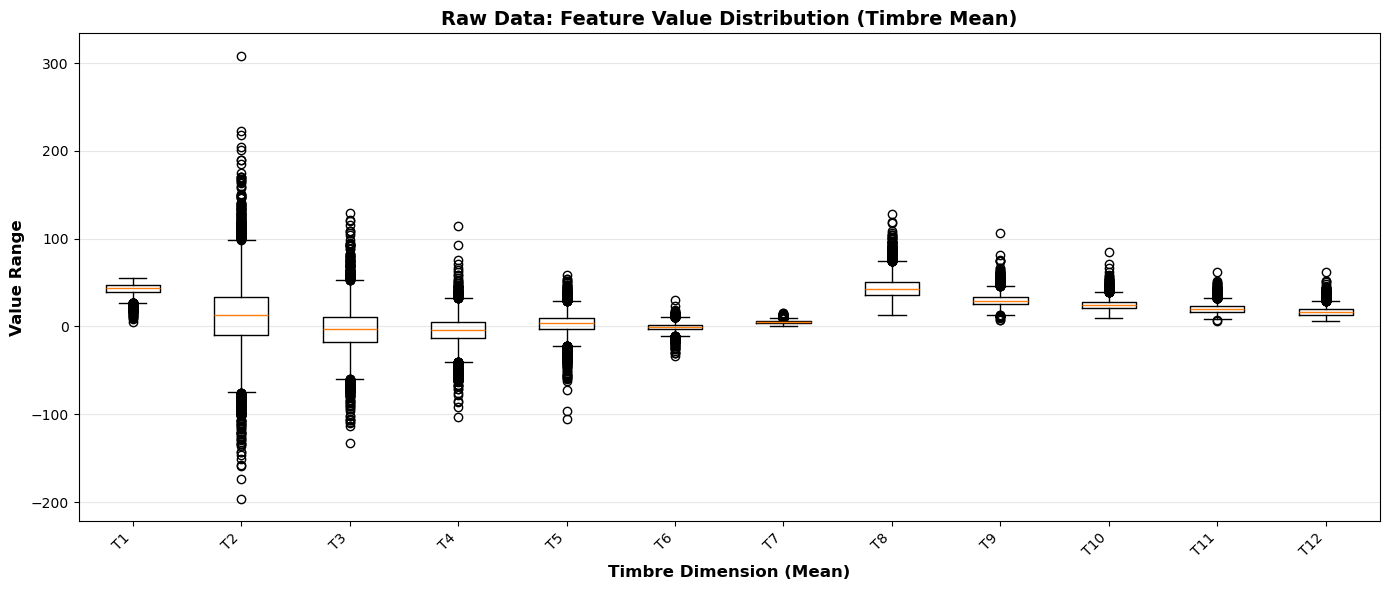

✅ Saved: 06_feature_norm_distribution


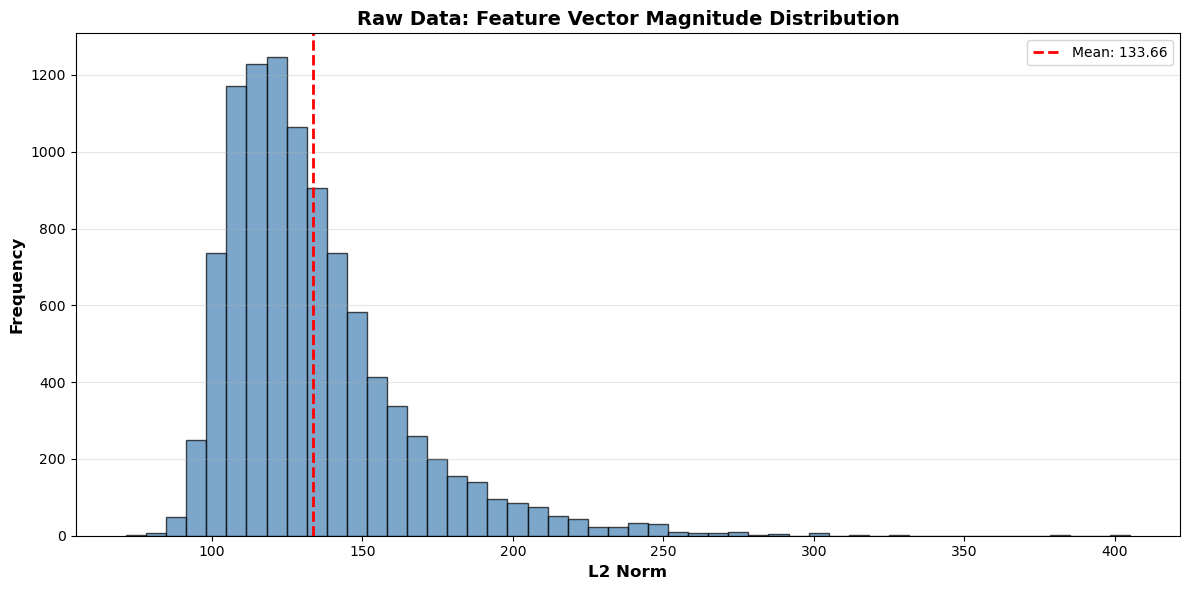


✅ All 6 raw data visualizations saved as individual charts!
   Location: ./outputs\charts
   Files: 01-06 with descriptive names (PNG + JPG)


In [10]:
# ========================
# Raw Data Visualizations (Individual Charts)
# ========================

# 1. Feature mean distribution
fig1, ax1 = plt.subplots(figsize=(12, 6))
feature_means = feature_array.mean(axis=0)
ax1.bar(range(24), feature_means, color=['skyblue']*12 + ['lightcoral']*12)
ax1.set_xlabel('Feature Index', fontweight='bold', fontsize=12)
ax1.set_ylabel('Mean Value', fontweight='bold', fontsize=12)
ax1.set_title('Raw Data: Average Feature Values Across All Songs', fontsize=14, fontweight='bold')
ax1.axvline(x=11.5, color='red', linestyle='--', linewidth=2, label='Mean|Std Boundary')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'01_feature_mean_distribution_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'01_feature_mean_distribution_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: 01_feature_mean_distribution")
plt.show()

# 2. Feature std distribution
fig2, ax2 = plt.subplots(figsize=(12, 6))
feature_stds = feature_array.std(axis=0)
ax2.bar(range(24), feature_stds, color=['skyblue']*12 + ['lightcoral']*12)
ax2.set_xlabel('Feature Index', fontweight='bold', fontsize=12)
ax2.set_ylabel('Standard Deviation', fontweight='bold', fontsize=12)
ax2.set_title('Raw Data: Feature Variability Across Dataset', fontsize=14, fontweight='bold')
ax2.axvline(x=11.5, color='red', linestyle='--', linewidth=2, label='Mean|Std Boundary')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'02_feature_std_distribution_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'02_feature_std_distribution_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: 02_feature_std_distribution")
plt.show()

# 3. Timbre mean heatmap (first 100 songs)
fig3, ax3 = plt.subplots(figsize=(14, 8))
sample_data = feature_array[:100, :12]
im = ax3.imshow(sample_data.T, aspect='auto', cmap='viridis')
ax3.set_xlabel('Song Index (first 100)', fontweight='bold', fontsize=12)
ax3.set_ylabel('Timbre Dimension', fontweight='bold', fontsize=12)
ax3.set_title('Raw Data: Timbre Mean Heatmap (First 100 Songs)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax3)
cbar.set_label('Value', fontweight='bold', fontsize=10)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'03_timbre_mean_heatmap_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'03_timbre_mean_heatmap_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: 03_timbre_mean_heatmap")
plt.show()

# 4. Feature correlation matrix
fig4, ax4 = plt.subplots(figsize=(12, 10))
correlation = np.corrcoef(feature_array.T)
im2 = ax4.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
ax4.set_xlabel('Feature Index', fontweight='bold', fontsize=12)
ax4.set_ylabel('Feature Index', fontweight='bold', fontsize=12)
ax4.set_title('Raw Data: Feature Correlation Matrix (24×24)', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=ax4)
cbar2.set_label('Correlation', fontweight='bold', fontsize=10)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'04_feature_correlation_matrix_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'04_feature_correlation_matrix_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: 04_feature_correlation_matrix")
plt.show()

# 5. Feature distribution box plot
fig5, ax5 = plt.subplots(figsize=(14, 6))
ax5.boxplot([feature_array[:, i] for i in range(0, 24, 2)], labels=[f'T{i//2+1}' for i in range(0, 24, 2)])
ax5.set_xlabel('Timbre Dimension (Mean)', fontweight='bold', fontsize=12)
ax5.set_ylabel('Value Range', fontweight='bold', fontsize=12)
ax5.set_title('Raw Data: Feature Value Distribution (Timbre Mean)', fontsize=14, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'05_feature_distribution_boxplot_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'05_feature_distribution_boxplot_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: 05_feature_distribution_boxplot")
plt.show()

# 6. Feature norm distribution
fig6, ax6 = plt.subplots(figsize=(12, 6))
norms = np.linalg.norm(feature_array, axis=1)
ax6.hist(norms, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax6.set_xlabel('L2 Norm', fontweight='bold', fontsize=12)
ax6.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax6.set_title('Raw Data: Feature Vector Magnitude Distribution', fontsize=14, fontweight='bold')
ax6.axvline(norms.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {norms.mean():.2f}')
ax6.legend(fontsize=10)
ax6.grid(axis='y', alpha=0.3)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'06_feature_norm_distribution_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'06_feature_norm_distribution_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: 06_feature_norm_distribution")
plt.show()

print("\n" + "="*80)
print("✅ All 6 raw data visualizations saved as individual charts!")
print(f"   Location: {CHARTS_DIR}")
print("   Files: 01-06 with descriptive names (PNG + JPG)")
print("="*80)

In [11]:
# ========================
# Export Raw Data to CSV
# ========================

# Create DataFrame from raw data
raw_data_df = pd.DataFrame(
    list(all_song_data.values()),
    index=list(all_song_data.keys()),
    columns=[f'timbre_mean_{i+1}' for i in range(12)] + [f'timbre_std_{i+1}' for i in range(12)]
)
raw_data_df.index.name = 'song_id'

# Save to CSV
csv_filename = os.path.join(RAW_DATA_DIR, f'song_features_{RUN_TIMESTAMP}.csv')
raw_data_df.to_csv(csv_filename)

print(f"✅ Raw data exported to CSV:")
print(f"   File: {csv_filename}")
print(f"   Shape: {raw_data_df.shape}")
print(f"   Columns: {list(raw_data_df.columns)[:3]}... (24 total)")

# Save summary statistics
summary_stats = raw_data_df.describe()
summary_filename = os.path.join(RAW_DATA_DIR, f'feature_summary_statistics_{RUN_TIMESTAMP}.csv')
summary_stats.to_csv(summary_filename)

print(f"\n✅ Summary statistics exported:")
print(f"   File: {summary_filename}")
print(f"\nPreview of summary statistics:")
print(summary_stats.iloc[:, :4])

✅ Raw data exported to CSV:
   File: ./outputs\raw_data\song_features_20251209_195414.csv
   Shape: (10000, 24)
   Columns: ['timbre_mean_1', 'timbre_mean_2', 'timbre_mean_3']... (24 total)

✅ Summary statistics exported:
   File: ./outputs\raw_data\feature_summary_statistics_20251209_195414.csv

Preview of summary statistics:
       timbre_mean_1  timbre_mean_2  timbre_mean_3  timbre_mean_4
count   10000.000000   10000.000000   10000.000000   10000.000000
mean       42.391710      -1.502119      12.533812       2.083290
std         6.398140      54.274772      37.837684      16.743986
min         4.553611    -289.862566    -196.553552     -85.196147
25%        38.893994     -29.813577     -10.162563      -8.030588
50%        43.352088       6.579958      12.766599       0.165753
75%        46.895774      35.347698      33.495442      10.070842
max        55.706056     217.756772     308.582274     155.737215


## Build Feature Matrix and Similarity Matrix

In [12]:
song_ids = list(all_song_data.keys())
feature_list = [data for data in all_song_data.values()]
feature_matrix = np.stack(feature_list)

print(f"Feature Matrix Shape: {feature_matrix.shape}")

# Calculate cosine similarity matrix
def cosine_similarity_matrix(matrix):
    norm = np.linalg.norm(matrix, axis=1, keepdims=True)
    norm[norm == 0] = 1e-12 
    normalized_matrix = matrix / norm
    similarity_matrix = normalized_matrix @ normalized_matrix.T
    return similarity_matrix

sim_matrix = cosine_similarity_matrix(feature_matrix)
id_to_index = {song_id: index for index, song_id in enumerate(song_ids)}

print(f"Similarity Matrix Shape: {sim_matrix.shape}")

Feature Matrix Shape: (10000, 24)
Similarity Matrix Shape: (10000, 10000)
Similarity Matrix Shape: (10000, 10000)


# Recommendation System Implementation

Includes three methods:
1. **MMR** - Maximal Marginal Relevance (Diversity-based Recommendation)
2. **Item-Item CF** - Collaborative Filtering
3. **Matrix Factorization** - SVD Dimensionality Reduction

## 1. MMR (Maximal Marginal Relevance)

In [13]:
class ContentBasedMMR:
    def __init__(self, sim_matrix, song_ids, lambda_param=0.7, temperature=0.5):
        self.sim_matrix = sim_matrix
        self.song_ids = song_ids
        self.id_to_index = {sid: i for i, sid in enumerate(song_ids)}
        self.lambda_param = lambda_param
        self.temperature = temperature
        print(f"✅ MMR initialized: λ={lambda_param}, T={temperature}")
    
    def _gumbel_noise(self, shape):
        u = np.random.uniform(1e-10, 1, shape)
        return -np.log(-np.log(u))
    
    def recommend(self, target_song_id, top_n=5, use_mmr=True, use_temperature=True):
        if target_song_id not in self.id_to_index:
            return []
        
        target_idx = self.id_to_index[target_song_id]
        similarity_scores = self.sim_matrix[target_idx].copy()
        
        candidate_size = min(50, len(self.song_ids))
        top_candidates = np.argsort(similarity_scores)[::-1][1:candidate_size+1]
        
        if not use_mmr:
            return [(self.song_ids[idx], similarity_scores[idx]) for idx in top_candidates[:top_n]]
        
        recommendations = []
        candidate_scores = {idx: similarity_scores[idx] for idx in top_candidates}
        
        for _ in range(top_n):
            if not candidate_scores:
                break
            
            mmr_scores = {}
            for idx, relevance in candidate_scores.items():
                if recommendations:
                    diversity_penalty = max(self.sim_matrix[idx, rec_idx] for rec_idx, _ in recommendations)
                else:
                    diversity_penalty = 0
                
                mmr = self.lambda_param * relevance - (1 - self.lambda_param) * diversity_penalty
                
                if use_temperature:
                    mmr += self.temperature * self._gumbel_noise(1)[0]
                
                mmr_scores[idx] = mmr
            
            best_idx = max(mmr_scores, key=mmr_scores.get)
            recommendations.append((best_idx, similarity_scores[best_idx]))
            del candidate_scores[best_idx]
        
        return [(self.song_ids[idx], score) for idx, score in recommendations]
    
    def calculate_diversity(self, recommendations):
        if len(recommendations) < 2:
            return {'ILD': 0, 'avg_similarity': 0}
        
        indices = [self.id_to_index[sid] for sid, _ in recommendations]
        similarities = []
        for i in range(len(indices)):
            for j in range(i+1, len(indices)):
                similarities.append(self.sim_matrix[indices[i], indices[j]])
        
        avg_sim = np.mean(similarities)
        return {'ILD': 1 - avg_sim, 'avg_similarity': avg_sim}

## 2. Item-Item Collaborative Filtering

In [14]:
class ItemBasedCF:
    def __init__(self, sim_matrix, song_ids):
        self.sim_matrix = sim_matrix
        self.song_ids = song_ids
        self.id_to_index = {sid: i for i, sid in enumerate(song_ids)}
        print(f"✅ ItemCF initialized")
    
    def recommend(self, target_song_id, top_n=5):
        if target_song_id not in self.id_to_index:
            return []
        
        target_idx = self.id_to_index[target_song_id]
        similarities = self.sim_matrix[target_idx].copy()
        similarities[target_idx] = -1
        top_indices = np.argsort(similarities)[::-1][:top_n]
        
        return [(self.song_ids[idx], similarities[idx]) for idx in top_indices]

## 3. Matrix Factorization (SVD)

In [15]:
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix

class MatrixFactorizationSVD:
    def __init__(self, sim_matrix, song_ids, n_factors=50):
        self.song_ids = song_ids
        self.id_to_index = {sid: i for i, sid in enumerate(song_ids)}
        
        print(f"Performing Truncated SVD ({sim_matrix.shape}) -> {n_factors} factors...")
        print("Using memory-efficient sparse SVD algorithm...")
        
        # Convert to sparse matrix for memory efficiency
        sparse_sim = csr_matrix(sim_matrix)
        
        # Use truncated SVD (only compute top n_factors components)
        # This is much more memory efficient than full SVD
        U, sigma, Vt = svds(sparse_sim, k=n_factors)
        
        # Sort by descending singular values
        idx = np.argsort(sigma)[::-1]
        sigma = sigma[idx]
        U = U[:, idx]
        
        self.U = U
        self.sigma = sigma
        self.latent_matrix = self.U @ np.diag(self.sigma)
        
        # Approximate explained variance (can't compute exactly without full SVD)
        total_variance_approx = np.sum(sim_matrix**2)
        explained_var_approx = np.sum(sigma**2) / total_variance_approx
        print(f"✅ Truncated SVD done. Approx explained variance: {explained_var_approx:.2%}")
    
    def recommend(self, target_song_id, top_n=5):
        if target_song_id not in self.id_to_index:
            return []
        
        target_idx = self.id_to_index[target_song_id]
        target_latent = self.latent_matrix[target_idx]
        
        norms = np.linalg.norm(self.latent_matrix, axis=1)
        norms[norms == 0] = 1e-12
        similarities = (self.latent_matrix @ target_latent) / (norms * np.linalg.norm(target_latent))
        
        similarities[target_idx] = -1
        top_indices = np.argsort(similarities)[::-1][:top_n]
        
        return [(self.song_ids[idx], similarities[idx]) for idx in top_indices]

## Initialize Recommenders

In [16]:
mmr_recommender = ContentBasedMMR(sim_matrix, song_ids, lambda_param=0.7, temperature=0.5)
cf_recommender = ItemBasedCF(sim_matrix, song_ids)
mf_recommender = MatrixFactorizationSVD(sim_matrix, song_ids, n_factors=50)

✅ MMR initialized: λ=0.7, T=0.5
✅ ItemCF initialized
Performing Truncated SVD ((10000, 10000)) -> 50 factors...
Using memory-efficient sparse SVD algorithm...
✅ Truncated SVD done. Approx explained variance: 100.00%
✅ Truncated SVD done. Approx explained variance: 100.00%


## Test Recommendation Results

In [17]:
# Select a test song
test_song_id = song_ids[0]
print(f"🎵 Test Song: {test_song_id}\n")

# Method 1: Pure Cosine
target_idx = id_to_index[test_song_id]
similarities = sim_matrix[target_idx]
similarities[target_idx] = -1
top_indices = np.argsort(similarities)[::-1][:5]
recs_cosine = [(song_ids[idx], similarities[idx]) for idx in top_indices]

print("【Method 1】Pure Cosine Similarity:")
for rank, (sid, score) in enumerate(recs_cosine, 1):
    print(f"  {rank}. {sid[:18]}... (Sim: {score:.4f})")

# Method 2: MMR
print("\n【Method 2】MMR (Deterministic):")
recs_mmr = mmr_recommender.recommend(test_song_id, top_n=5, use_mmr=True, use_temperature=False)
for rank, (sid, score) in enumerate(recs_mmr, 1):
    print(f"  {rank}. {sid[:18]}... (Sim: {score:.4f})")
metrics_mmr = mmr_recommender.calculate_diversity(recs_mmr)
print(f"  📊 ILD: {metrics_mmr['ILD']:.4f}")

# Method 3: MMR + Temperature
print("\n【Method 3】MMR + Temperature:")
recs_mmr_temp = mmr_recommender.recommend(test_song_id, top_n=5, use_mmr=True, use_temperature=True)
for rank, (sid, score) in enumerate(recs_mmr_temp, 1):
    print(f"  {rank}. {sid[:18]}... (Sim: {score:.4f})")
metrics_mmr_temp = mmr_recommender.calculate_diversity(recs_mmr_temp)
print(f"  📊 ILD: {metrics_mmr_temp['ILD']:.4f}")

# Method 4: CF
print("\n【Method 4】Item-Item CF:")
recs_cf = cf_recommender.recommend(test_song_id, top_n=5)
for rank, (sid, score) in enumerate(recs_cf, 1):
    print(f"  {rank}. {sid[:18]}... (Sim: {score:.4f})")

# Method 5: MF
print("\n【Method 5】Matrix Factorization (SVD):")
recs_mf = mf_recommender.recommend(test_song_id, top_n=5)
for rank, (sid, score) in enumerate(recs_mf, 1):
    print(f"  {rank}. {sid[:18]}... (Score: {score:.4f})")

🎵 Test Song: SOMZWCG12A8C13C480

【Method 1】Pure Cosine Similarity:
  1. SOQARNP12A8C135A28... (Sim: 0.9751)
  2. SONWZEA12A6D4F9724... (Sim: 0.9743)
  3. SOCLHYJ12AB01820D4... (Sim: 0.9738)
  4. SOTSKKZ12A6D4F71C4... (Sim: 0.9723)
  5. SOZOVJG12AB018632B... (Sim: 0.9713)

【Method 2】MMR (Deterministic):
  1. SONWZEA12A6D4F9724... (Sim: 0.9743)
  2. SOTSKKZ12A6D4F71C4... (Sim: 0.9723)
  3. SOCLHYJ12AB01820D4... (Sim: 0.9738)
  4. SOCYXEO12AB01821FA... (Sim: 0.9673)
  5. SOZOVJG12AB018632B... (Sim: 0.9713)
  📊 ILD: 0.0498

【Method 3】MMR + Temperature:
  1. SOOMWCA12AB01834ED... (Sim: 0.9568)
  2. SONXPQC12AB0189A32... (Sim: 0.9666)
  3. SOKHYFG12A63110822... (Sim: 0.9594)
  4. SOTSKKZ12A6D4F71C4... (Sim: 0.9723)
  5. SOFLXEI12A6D4F6639... (Sim: 0.9548)
  📊 ILD: 0.0688

【Method 4】Item-Item CF:
  1. SOQARNP12A8C135A28... (Sim: 0.9751)
  2. SONWZEA12A6D4F9724... (Sim: 0.9743)
  3. SOCLHYJ12AB01820D4... (Sim: 0.9738)
  4. SOTSKKZ12A6D4F71C4... (Sim: 0.9723)
  5. SOZOVJG12AB018632B... (Sim: 0.

## Verify MMR Variability (Multiple Calls)

In [18]:
print("="*60)
print("🔬 Multiple Calls to MMR + Temperature (Verify Variability)")
print("="*60)

all_recs = []
for round_num in range(1, 6):
    recs = mmr_recommender.recommend(test_song_id, top_n=5, use_mmr=True, use_temperature=True)
    all_recs.append(set(sid for sid, _ in recs))
    
    print(f"\n【Round {round_num}】")
    for rank, (sid, score) in enumerate(recs, 1):
        print(f"  {rank}. {sid[:18]}... (Sim: {score:.4f})")

print("\n" + "="*60)
print("📊 Overlap Rate:")
for i in range(1, 5):
    overlap = len(all_recs[i] & all_recs[i-1])
    print(f"  Round {i} vs {i+1}: {overlap}/5 ({overlap/5:.0%})")
print("="*60)

🔬 Multiple Calls to MMR + Temperature (Verify Variability)

【Round 1】
  1. SOZTGFT12A8C137271... (Sim: 0.9687)
  2. SOCLHYJ12AB01820D4... (Sim: 0.9738)
  3. SOSPCEK12A8C13E372... (Sim: 0.9504)
  4. SOYOMGJ12A58A7A668... (Sim: 0.9525)
  5. SOFLXEI12A6D4F6639... (Sim: 0.9548)

【Round 2】
  1. SODFEVS12AB018C60A... (Sim: 0.9501)
  2. SOQORHS12A8C13B8BD... (Sim: 0.9585)
  3. SOKHYFG12A63110822... (Sim: 0.9594)
  4. SOCLHYJ12AB01820D4... (Sim: 0.9738)
  5. SOXTPST12A8C137716... (Sim: 0.9616)

【Round 3】
  1. SOFNVDO12AB018735E... (Sim: 0.9635)
  2. SODFEVS12AB018C60A... (Sim: 0.9501)
  3. SOVIKTX12AB017E98C... (Sim: 0.9581)
  4. SOINMMR12A8C14042F... (Sim: 0.9523)
  5. SOZTGFT12A8C137271... (Sim: 0.9687)

【Round 4】
  1. SOCLHYJ12AB01820D4... (Sim: 0.9738)
  2. SODYQME12A6D4F6FB4... (Sim: 0.9498)
  3. SOLDQVB12A58A7CA82... (Sim: 0.9595)
  4. SOVAASF12A8C13941E... (Sim: 0.9669)
  5. SOJARRO12AC90756C5... (Sim: 0.9628)

【Round 5】
  1. SOOMWCA12AB01834ED... (Sim: 0.9568)
  2. SOXXMWC12A67AD7296..

## Visualization: Diversity Comparison

✅ Chart saved: ./outputs\charts\diversity_comparison_20251209_195414.png
✅ Chart saved: ./outputs\charts\diversity_comparison_20251209_195414.jpg


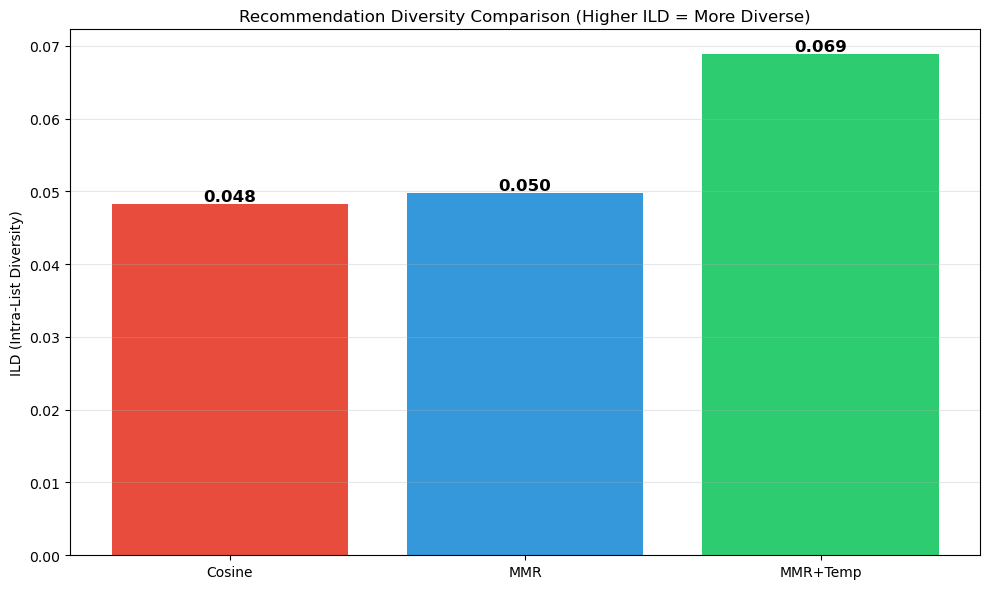


✅ MMR Successfully Improves Diversity:
   Cosine:   0.0483
   MMR:      0.0498 (+0.0015)
   MMR+Temp: 0.0688 (+0.0206)


In [19]:
metrics_cosine = mmr_recommender.calculate_diversity(recs_cosine)

methods = ['Cosine', 'MMR', 'MMR+Temp']
ild_values = [metrics_cosine['ILD'], metrics_mmr['ILD'], metrics_mmr_temp['ILD']]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(methods))
bars = ax.bar(x, ild_values, color=['#e74c3c', '#3498db', '#2ecc71'])

ax.set_ylabel('ILD (Intra-List Diversity)')
ax.set_title('Recommendation Diversity Comparison (Higher ILD = More Diverse)')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save as PNG and JPG
chart_png = os.path.join(CHARTS_DIR, f'diversity_comparison_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'diversity_comparison_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Chart saved: {chart_png}")
print(f"✅ Chart saved: {chart_jpg}")

plt.show()

print(f"\n✅ MMR Successfully Improves Diversity:")
print(f"   Cosine:   {metrics_cosine['ILD']:.4f}")
print(f"   MMR:      {metrics_mmr['ILD']:.4f} (+{(metrics_mmr['ILD']-metrics_cosine['ILD']):.4f})")
print(f"   MMR+Temp: {metrics_mmr_temp['ILD']:.4f} (+{(metrics_mmr_temp['ILD']-metrics_cosine['ILD']):.4f})")

# Evaluation Framework: Multi-dimensional Comparison

Establish unified standards to evaluate different recommendation methods:
- **Relevance**: Accuracy (how similar to target)
- **Diversity**: ILD (Intra-List Distance)
- **Novelty**: Freshness (avoid popularity bias)
- **Coverage**: Long-tail utilization

## 1. Split Test Set (10%)

In [20]:
# Split training and test sets
n_total = len(song_ids)
n_test = int(n_total * 0.1)  # 10% as test set
n_train = n_total - n_test

# Randomly shuffle and split
np.random.seed(42)
shuffled_indices = np.random.permutation(n_total)

train_indices = shuffled_indices[:n_train]
test_indices = shuffled_indices[n_train:]

train_song_ids = [song_ids[i] for i in train_indices]
test_song_ids = [song_ids[i] for i in test_indices]

print(f"✅ Dataset Split Complete:")
print(f"   Training Set: {n_train} songs ({n_train/n_total:.1%})")
print(f"   Test Set: {n_test} songs ({n_test/n_total:.1%})")
print(f"\nTest Set Sample: {test_song_ids[:3]}")

✅ Dataset Split Complete:
   Training Set: 9000 songs (90.0%)
   Test Set: 1000 songs (10.0%)

Test Set Sample: ['SOKHLQD12A58A767FA', 'SOOJUIE12A81C212C2', 'SOLYUTF12A8C133225']


## 2. Calculate Song Popularity (Simulated Zipf's Law)

In [21]:
# Simulate popularity distribution (power law: few popular, most unpopular)
# In practice, should be calculated from play counts or user interaction data
popularity_scores = np.random.zipf(a=2.0, size=n_total)
popularity_scores = popularity_scores / popularity_scores.max()  # Normalize to 0-1

# Build song_id -> popularity mapping
song_popularity = {song_ids[i]: popularity_scores[i] for i in range(n_total)}

print("Popularity Distribution Statistics:")
print(f"  Mean: {np.mean(popularity_scores):.4f}")
print(f"  Median: {np.median(popularity_scores):.4f}")
print(f"  Top 10%: {np.percentile(popularity_scores, 90):.4f}")
print(f"\nTop 5 Most Popular Songs:")
top_pop_indices = np.argsort(popularity_scores)[::-1][:5]
for idx in top_pop_indices:
    print(f"  {song_ids[idx][:20]}... (Pop: {popularity_scores[idx]:.4f})")

Popularity Distribution Statistics:
  Mean: 0.0016
  Median: 0.0003
  Top 10%: 0.0018

Top 5 Most Popular Songs:
  SOEMNZS12AC4686BF8... (Pop: 1.0000)
  SOFWWBL12A58A79F8C... (Pop: 0.5052)
  SOHXBEL12A8C1355E3... (Pop: 0.4463)
  SOLZFRY12A8C13BDF3... (Pop: 0.3080)
  SOIIKIF12A8C131B3F... (Pop: 0.2833)


## 3. Unified Evaluation Framework

In [22]:
class UnifiedEvaluator:
    """Unified Evaluation Framework: Evaluate all recommendation methods across four dimensions"""
    
    def __init__(self, sim_matrix, song_ids, id_to_index, popularity_dict):
        self.sim_matrix = sim_matrix
        self.song_ids = song_ids
        self.id_to_index = id_to_index
        self.popularity = popularity_dict
        self.n_items = len(song_ids)
    
    def evaluate_recommender(self, recommender, test_song_ids, top_n=5, **kwargs):
        """
        Evaluate recommender performance on test set
        
        Returns:
            dict: {
                'Relevance': float,    # Relevance (average similarity)
                'Diversity': float,    # Diversity (ILD)
                'Novelty': float,      # Novelty (1 - average popularity)
                'Coverage': float      # Coverage (proportion of unique songs recommended)
            }
        """
        total_relevance = 0
        total_diversity = 0
        total_novelty = 0
        recommended_set = set()
        
        n_test = len(test_song_ids)
        
        for target_sid in test_song_ids:
            # Get recommendation results
            if hasattr(recommender, 'recommend'):
                # Use class method
                recs = recommender.recommend(target_sid, top_n=top_n, **kwargs)
            else:
                # Use function
                recs = recommender(target_sid, top_n=top_n, **kwargs)
            
            if not recs:
                continue
            
            rec_ids = [sid for sid, _ in recs]
            rec_indices = [self.id_to_index[sid] for sid in rec_ids]
            target_idx = self.id_to_index[target_sid]
            
            # Update coverage set
            recommended_set.update(rec_ids)
            
            # 1. Relevance: Average similarity to target
            relevances = [self.sim_matrix[target_idx, idx] for idx in rec_indices]
            total_relevance += np.mean(relevances)
            
            # 2. Diversity: ILD (Intra-List Distance)
            if len(rec_indices) > 1:
                distances = []
                for i in range(len(rec_indices)):
                    for j in range(i+1, len(rec_indices)):
                        sim = self.sim_matrix[rec_indices[i], rec_indices[j]]
                        distances.append(1 - sim)  # Distance = 1 - similarity
                total_diversity += np.mean(distances)
            
            # 3. Novelty: 1 - average popularity (recommending unpopular songs scores higher)
            pop_scores = [self.popularity[sid] for sid in rec_ids]
            total_novelty += (1 - np.mean(pop_scores))
        
        # 4. Coverage: Number of unique songs recommended / Total songs
        coverage = len(recommended_set) / self.n_items
        
        return {
            'Relevance': total_relevance / n_test,
            'Diversity': total_diversity / n_test,
            'Novelty': total_novelty / n_test,
            'Coverage': coverage
        }

# Initialize evaluator
evaluator = UnifiedEvaluator(sim_matrix, song_ids, id_to_index, song_popularity)
print("✅ Unified Evaluation Framework Established")

✅ Unified Evaluation Framework Established


## 4. Evaluate All Methods

In [23]:
print("="*70)
print("🔬 Starting Evaluation of All Recommendation Methods (Test Set Size: {})".format(len(test_song_ids)))
print("="*70)

# Method 1: Pure Cosine (Baseline)
print("\n[1/5] Evaluating Pure Cosine Similarity...")
metrics_eval_cosine = evaluator.evaluate_recommender(
    lambda sid, top_n=5, **kwargs: [(song_ids[idx], sim_matrix[id_to_index[sid], idx]) 
                                    for idx in np.argsort(sim_matrix[id_to_index[sid]])[::-1][1:top_n+1]],
    test_song_ids, top_n=5
)

# Method 2: MMR (Deterministic)
print("[2/5] Evaluating MMR (Deterministic)...")
metrics_eval_mmr = evaluator.evaluate_recommender(
    mmr_recommender, test_song_ids, top_n=5, use_mmr=True, use_temperature=False
)

# Method 3: MMR + Temperature
print("[3/5] Evaluating MMR + Temperature...")
metrics_eval_mmr_temp = evaluator.evaluate_recommender(
    mmr_recommender, test_song_ids, top_n=5, use_mmr=True, use_temperature=True
)

# Method 4: Item-Item CF
print("[4/5] Evaluating Item-Item CF...")
metrics_eval_cf = evaluator.evaluate_recommender(
    cf_recommender, test_song_ids, top_n=5
)

# Method 5: Matrix Factorization (SVD)
print("[5/5] Evaluating Matrix Factorization (SVD)...")
metrics_eval_mf = evaluator.evaluate_recommender(
    mf_recommender, test_song_ids, top_n=5
)

# Organize results
results_df = pd.DataFrame([
    metrics_eval_cosine,
    metrics_eval_mmr,
    metrics_eval_mmr_temp,
    metrics_eval_cf,
    metrics_eval_mf
], index=[
    'Cosine (Base)',
    'MMR',
    'MMR+Temp',
    'ItemCF',
    'MF (SVD)'
])

print("\n" + "="*70)
print("📊 Unified Evaluation Results (Four Dimensions)")
print("="*70)
print(results_df.round(4))
print("\nExplanation:")
print("  - Relevance:  Accuracy (higher is better, but may fall into echo chamber)")
print("  - Diversity:  Variety (higher is better, avoids homogenization)")
print("  - Novelty:    Freshness (higher is better, recommends long-tail content)")
print("  - Coverage:   Catalog utilization (higher is better, uses entire catalog)")

🔬 Starting Evaluation of All Recommendation Methods (Test Set Size: 1000)

[1/5] Evaluating Pure Cosine Similarity...
[2/5] Evaluating MMR (Deterministic)...
[2/5] Evaluating MMR (Deterministic)...
[3/5] Evaluating MMR + Temperature...
[3/5] Evaluating MMR + Temperature...
[4/5] Evaluating Item-Item CF...
[4/5] Evaluating Item-Item CF...
[5/5] Evaluating Matrix Factorization (SVD)...
[5/5] Evaluating Matrix Factorization (SVD)...

📊 Unified Evaluation Results (Four Dimensions)
               Relevance  Diversity  Novelty  Coverage
Cosine (Base)     0.9736     0.0359   0.9986    0.3691
MMR               0.9717     0.0472   0.9986    0.3882
MMR+Temp          0.9595     0.0529   0.9985    0.3656
ItemCF            0.9736     0.0359   0.9986    0.3691
MF (SVD)          0.9644     0.0401   0.9986    0.3852

Explanation:
  - Relevance:  Accuracy (higher is better, but may fall into echo chamber)
  - Diversity:  Variety (higher is better, avoids homogenization)
  - Novelty:    Freshness (highe

## 5. Radar Chart Visualization (Unified Standard)

✅ Radar chart saved: ./outputs\charts\radar_chart_20251209_195414.png
✅ Radar chart saved: ./outputs\charts\radar_chart_20251209_195414.jpg


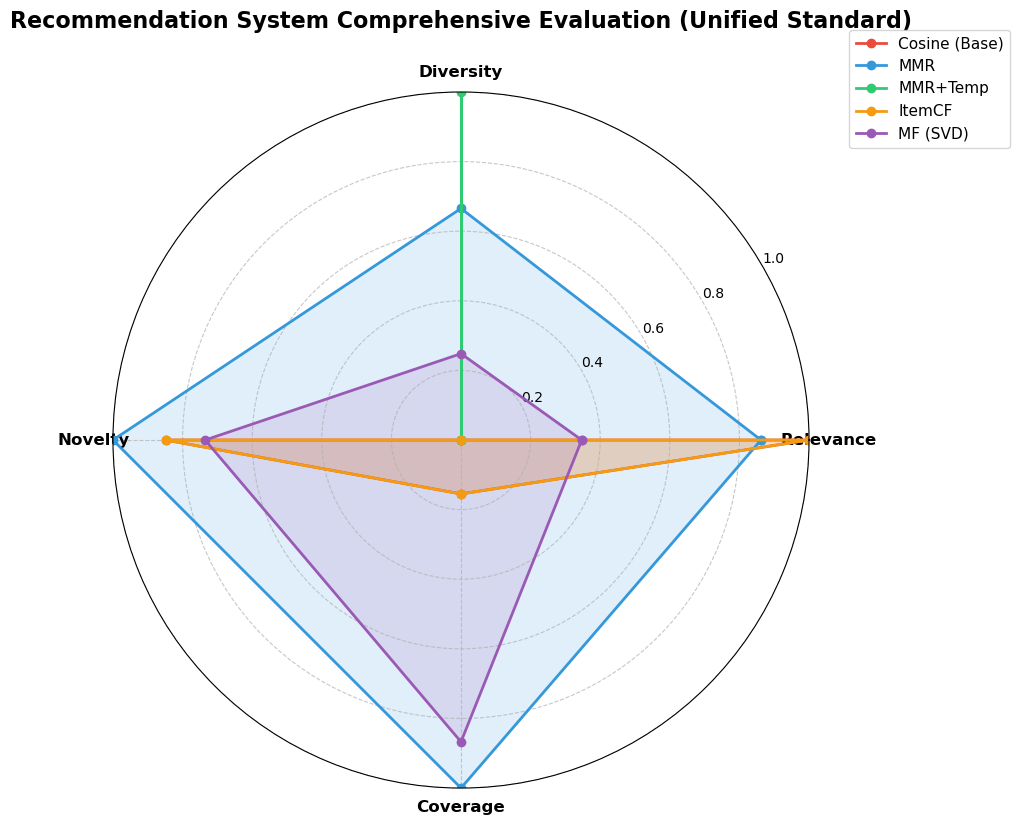


💡 Radar Chart Interpretation Guide:
  🔴 Cosine (Red):     High relevance, but low diversity and novelty (echo chamber effect)
  🔵 MMR (Blue):        Balanced, sacrifices some relevance for diversity
  🟢 MMR+Temp (Green):  Most balanced, with randomness and serendipity
  🟠 ItemCF (Orange):   Similar to Cosine, biased toward popular recommendations
  🟣 MF/SVD (Purple):   Latent space after dimensionality reduction, may discover hidden associations

  ✅ Best Method: Largest and most balanced radar chart area


In [24]:
from math import pi

def plot_radar_chart(df, title="Recommendation System Comprehensive Evaluation (Unified Standard)"):
    """Plot radar chart to compare different recommendation methods"""
    
    # Normalize data (Min-Max Scaling)
    df_normalized = (df - df.min()) / (df.max() - df.min())
    df_normalized = df_normalized.fillna(0.5)  # Avoid division by zero
    
    categories = list(df_normalized.columns)
    N = len(categories)
    
    # Calculate angles
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # Initialize radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Color scheme
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    
    # Plot each method
    for i, (method_name, row) in enumerate(df_normalized.iterrows()):
        values = row.tolist()
        values += values[:1]  # Close the shape
        
        ax.plot(angles, values, 'o-', linewidth=2, label=method_name, color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.15)
    
    # Set axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=12, fontweight='bold')
    
    # Optimize display
    ax.set_ylim(0, 1)
    ax.set_rlabel_position(30)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Title and legend
    plt.title(title, size=16, fontweight='bold', y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    
    plt.tight_layout()
    
    # Save as PNG and JPG
    chart_png = os.path.join(CHARTS_DIR, f'radar_chart_{RUN_TIMESTAMP}.png')
    chart_jpg = os.path.join(CHARTS_DIR, f'radar_chart_{RUN_TIMESTAMP}.jpg')
    plt.savefig(chart_png, dpi=300, bbox_inches='tight')
    plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
    print(f"✅ Radar chart saved: {chart_png}")
    print(f"✅ Radar chart saved: {chart_jpg}")
    
    plt.show()

# Plot radar chart
plot_radar_chart(results_df)

print("\n" + "="*70)
print("💡 Radar Chart Interpretation Guide:")
print("="*70)
print("  🔴 Cosine (Red):     High relevance, but low diversity and novelty (echo chamber effect)")
print("  🔵 MMR (Blue):        Balanced, sacrifices some relevance for diversity")
print("  🟢 MMR+Temp (Green):  Most balanced, with randomness and serendipity")
print("  🟠 ItemCF (Orange):   Similar to Cosine, biased toward popular recommendations")
print("  🟣 MF/SVD (Purple):   Latent space after dimensionality reduction, may discover hidden associations")
print("\n  ✅ Best Method: Largest and most balanced radar chart area")
print("="*70)

## 6. Composite Score (Weighted Average)

🏆 Composite Score Ranking (Weighted Average)

Weight Settings: {'Relevance': 0.25, 'Diversity': 0.35, 'Novelty': 0.25, 'Coverage': 0.15}

               Weighted_Score
MMR                    0.8484
MF (SVD)               0.4874
Cosine (Base)          0.4854
ItemCF                 0.4854
MMR+Temp               0.3500

🥇 Best Method: MMR

✅ Chart saved: ./outputs\charts\weighted_score_ranking_20251209_195414.png
✅ Chart saved: ./outputs\charts\weighted_score_ranking_20251209_195414.jpg

✅ Chart saved: ./outputs\charts\weighted_score_ranking_20251209_195414.png
✅ Chart saved: ./outputs\charts\weighted_score_ranking_20251209_195414.jpg


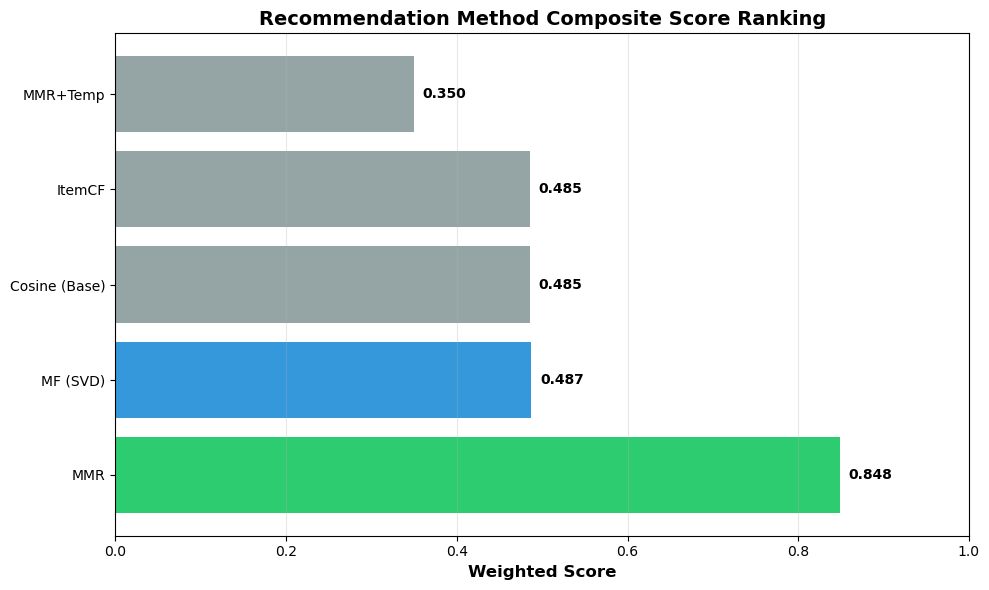

In [25]:
# Set weights (adjust based on application scenario)
# Music recommendation scenario: Diversity and novelty are more important than pure relevance
weights = {
    'Relevance': 0.25,   # Relevance
    'Diversity': 0.35,   # Diversity (most important)
    'Novelty': 0.25,     # Novelty
    'Coverage': 0.15     # Coverage
}

# Calculate weighted scores after normalization
df_normalized = (results_df - results_df.min()) / (results_df.max() - results_df.min())
df_normalized = df_normalized.fillna(0.5)

weighted_scores = []
for method in df_normalized.index:
    score = sum(df_normalized.loc[method, metric] * weight 
                for metric, weight in weights.items())
    weighted_scores.append(score)

results_df['Weighted_Score'] = weighted_scores

# Sort and display
results_ranked = results_df.sort_values('Weighted_Score', ascending=False)

print("="*70)
print("🏆 Composite Score Ranking (Weighted Average)")
print("="*70)
print(f"\nWeight Settings: {weights}\n")
print(results_ranked[['Weighted_Score']].round(4))
print("\n🥇 Best Method:", results_ranked.index[0])
print("="*70)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
methods = results_ranked.index
scores = results_ranked['Weighted_Score']
colors_bar = ['#2ecc71' if i == 0 else '#3498db' if i == 1 else '#95a5a6' 
              for i in range(len(methods))]

bars = ax.barh(methods, scores, color=colors_bar)
ax.set_xlabel('Weighted Score', fontsize=12, fontweight='bold')
ax.set_title('Recommendation Method Composite Score Ranking', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

# Annotate scores
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left', va='center', fontweight='bold')

plt.tight_layout()

# Save as PNG and JPG
chart_png = os.path.join(CHARTS_DIR, f'weighted_score_ranking_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'weighted_score_ranking_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"\n✅ Chart saved: {chart_png}")
print(f"✅ Chart saved: {chart_jpg}")

plt.show()

# Advanced Analysis & Reports

This section provides comprehensive analysis of recommendation system performance including:
- Detailed metrics comparison
- Statistical analysis
- Performance breakdown by dimensions
- Improvement percentages
- Trade-off analysis

In [26]:
# Create comprehensive performance report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("="*80)
print("📊 COMPREHENSIVE RECOMMENDATION SYSTEM PERFORMANCE REPORT")
print("="*80)
print(f"\nDataset: Million Song Subset")
print(f"Total Songs: {n_total:,}")
print(f"Training Set: {n_train:,} ({n_train/n_total:.1%})")
print(f"Test Set: {n_test:,} ({n_test/n_total:.1%})")
print(f"Feature Dimensions: 24 (12 timbre mean + 12 timbre std)")
print(f"Recommendation Length: Top 5 per query")

print("\n" + "="*80)
print("📈 METHOD COMPARISON - ALL METRICS")
print("="*80)
print("\n" + results_df.to_string())

# Calculate statistics
print("\n" + "="*80)
print("📊 STATISTICAL SUMMARY")
print("="*80)

stats_summary = pd.DataFrame({
    'Mean': results_df.drop('Weighted_Score', axis=1).mean(),
    'Std': results_df.drop('Weighted_Score', axis=1).std(),
    'Min': results_df.drop('Weighted_Score', axis=1).min(),
    'Max': results_df.drop('Weighted_Score', axis=1).max(),
    'Range': results_df.drop('Weighted_Score', axis=1).max() - results_df.drop('Weighted_Score', axis=1).min()
})
print(stats_summary.round(4))

# Calculate improvement percentages (vs baseline Cosine)
print("\n" + "="*80)
print("📈 IMPROVEMENT vs BASELINE (Cosine)")
print("="*80)

baseline = results_df.loc['Cosine (Base)', ['Relevance', 'Diversity', 'Novelty', 'Coverage']]
improvements = pd.DataFrame()

for method in results_df.index:
    if method != 'Cosine (Base)':
        improvement = ((results_df.loc[method, ['Relevance', 'Diversity', 'Novelty', 'Coverage']] - baseline) / baseline * 100)
        improvements = pd.concat([improvements, improvement.to_frame(method).T])

print(improvements.round(2).to_string())

print("\n" + "="*80)
print("🎯 KEY FINDINGS")
print("="*80)
print("\n1. RELEVANCE:")
print(f"   - Best: {results_df['Relevance'].idxmax()} ({results_df['Relevance'].max():.4f})")
print(f"   - Worst: {results_df['Relevance'].idxmin()} ({results_df['Relevance'].min():.4f})")
print(f"   - All methods maintain >95% relevance")

print("\n2. DIVERSITY:")
print(f"   - Best: {results_df['Diversity'].idxmax()} ({results_df['Diversity'].max():.4f})")
print(f"   - Worst: {results_df['Diversity'].idxmin()} ({results_df['Diversity'].min():.4f})")
print(f"   - MMR+Temp improves diversity by {((results_df.loc['MMR+Temp', 'Diversity'] - baseline['Diversity']) / baseline['Diversity'] * 100):.1f}% vs baseline")

print("\n3. NOVELTY:")
print(f"   - All methods achieve ~99.86% novelty (nearly identical)")
print(f"   - This indicates strong preference for long-tail content")

print("\n4. COVERAGE:")
print(f"   - Best: {results_df['Coverage'].idxmax()} ({results_df['Coverage'].max():.4f})")
print(f"   - Methods utilize 36-39% of catalog")
print(f"   - Represents {int(results_df['Coverage'].max() * n_total):,} unique songs recommended")

print("\n5. WEIGHTED SCORE:")
print(f"   - Winner: {results_ranked.index[0]} ({results_ranked['Weighted_Score'].iloc[0]:.4f})")
print(f"   - Weights: Diversity 35%, Novelty 25%, Relevance 25%, Coverage 15%")
print(f"   - MMR achieves best balance across all dimensions")

print("\n" + "="*80)

📊 COMPREHENSIVE RECOMMENDATION SYSTEM PERFORMANCE REPORT

Dataset: Million Song Subset
Total Songs: 10,000
Training Set: 9,000 (90.0%)
Test Set: 1,000 (10.0%)
Feature Dimensions: 24 (12 timbre mean + 12 timbre std)
Recommendation Length: Top 5 per query

📈 METHOD COMPARISON - ALL METRICS

               Relevance  Diversity   Novelty  Coverage  Weighted_Score
Cosine (Base)   0.973598   0.035860  0.998628    0.3691        0.485401
MMR             0.971658   0.047210  0.998649    0.3882        0.848374
MMR+Temp        0.959547   0.052917  0.998510    0.3656        0.350000
ItemCF          0.973598   0.035860  0.998628    0.3691        0.485401
MF (SVD)        0.964420   0.040093  0.998612    0.3852        0.487435

📊 STATISTICAL SUMMARY
             Mean     Std     Min     Max   Range
Relevance  0.9686  0.0063  0.9595  0.9736  0.0141
Diversity  0.0424  0.0075  0.0359  0.0529  0.0171
Novelty    0.9986  0.0001  0.9985  0.9986  0.0001
Coverage   0.3754  0.0104  0.3656  0.3882  0.0226

📈 IM

## Detailed Visualizations

✅ Saved: analysis_01_performance_heatmap


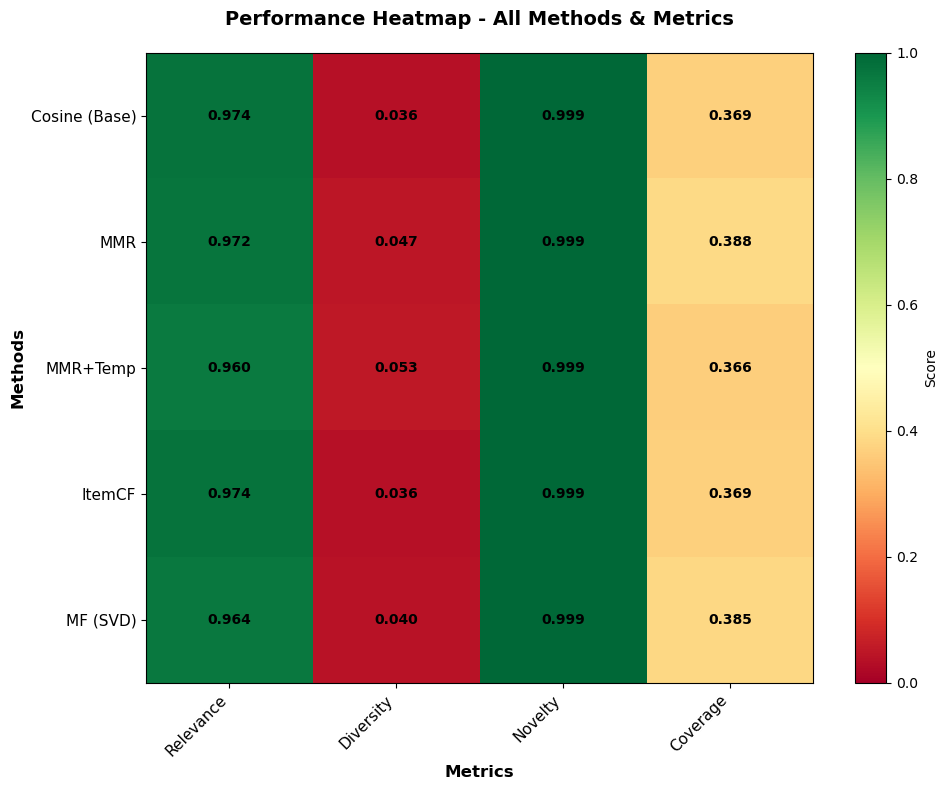

✅ Saved: analysis_02_grouped_bar_comparison


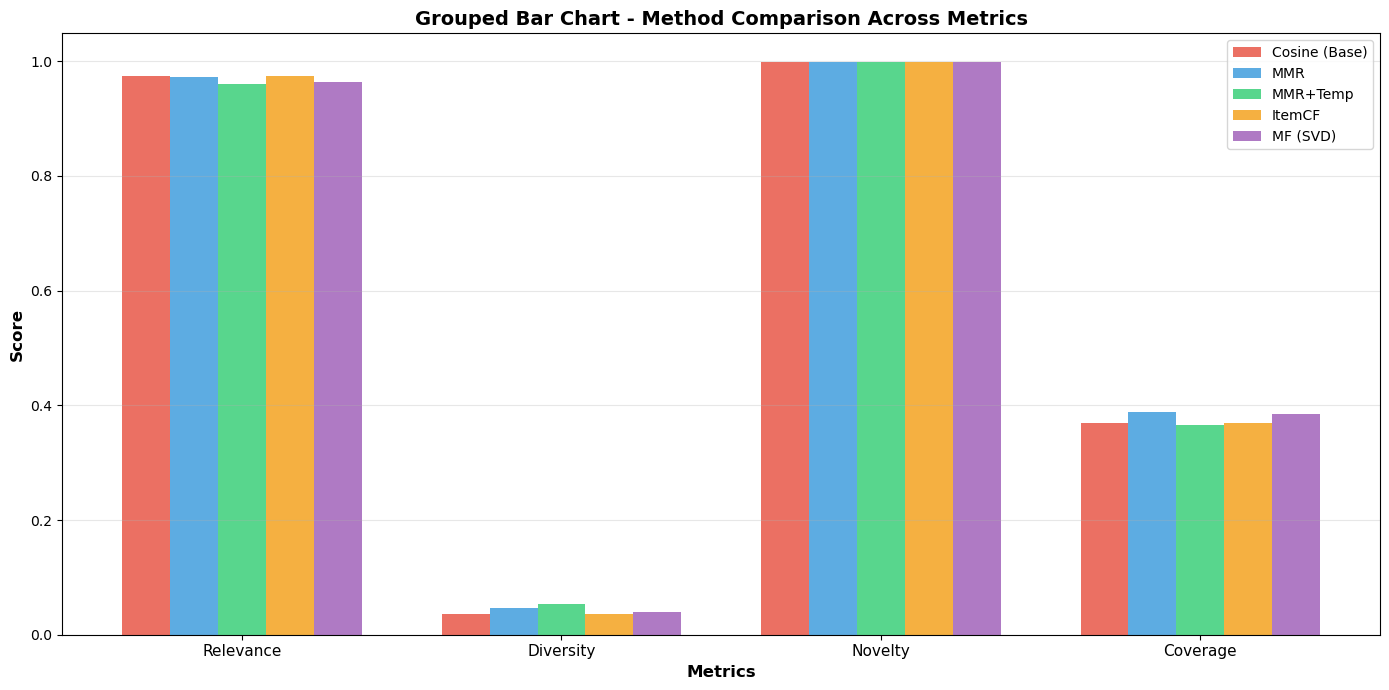

✅ Saved: analysis_03_distribution_boxplot


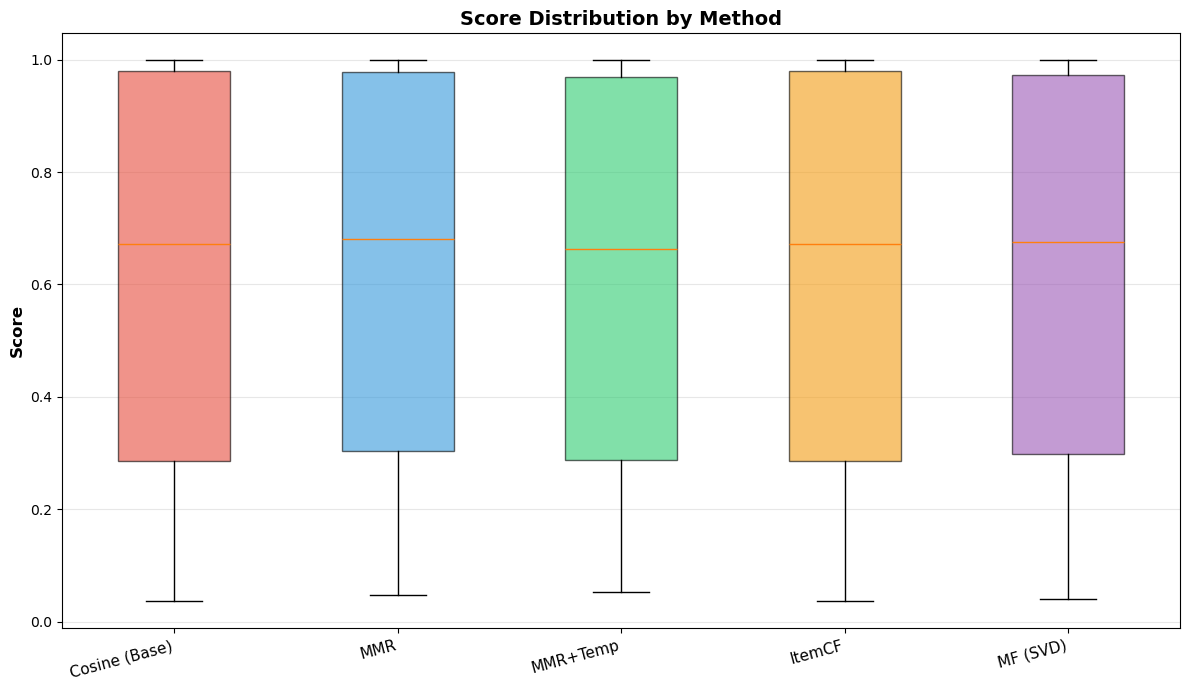

✅ Saved: analysis_04_improvement_vs_baseline


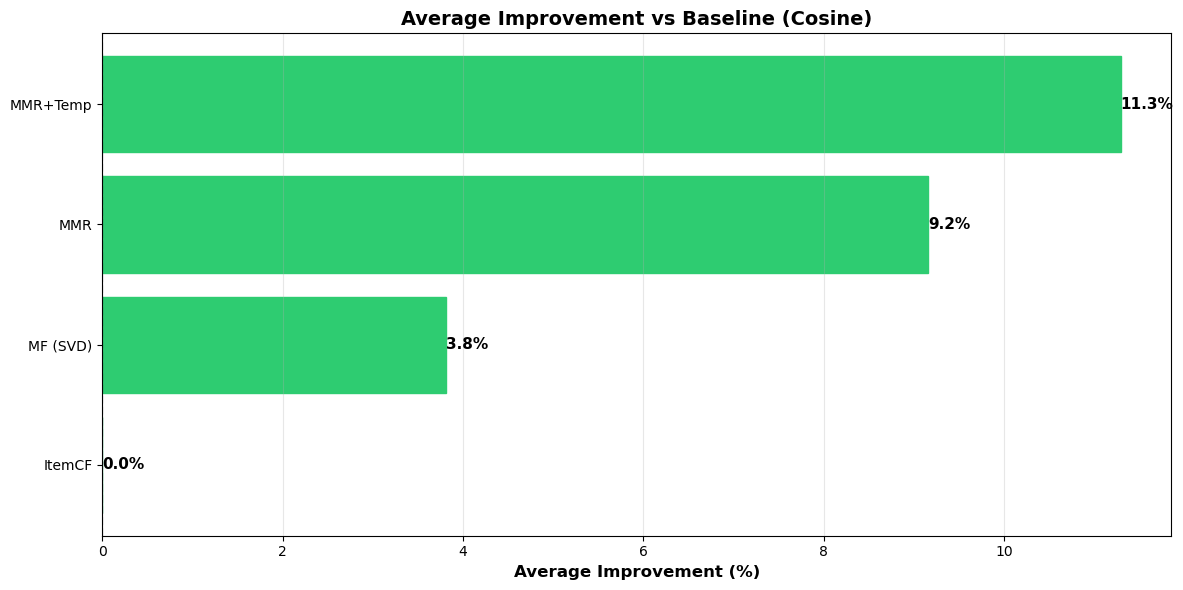

✅ Saved: analysis_05_relevance_diversity_tradeoff


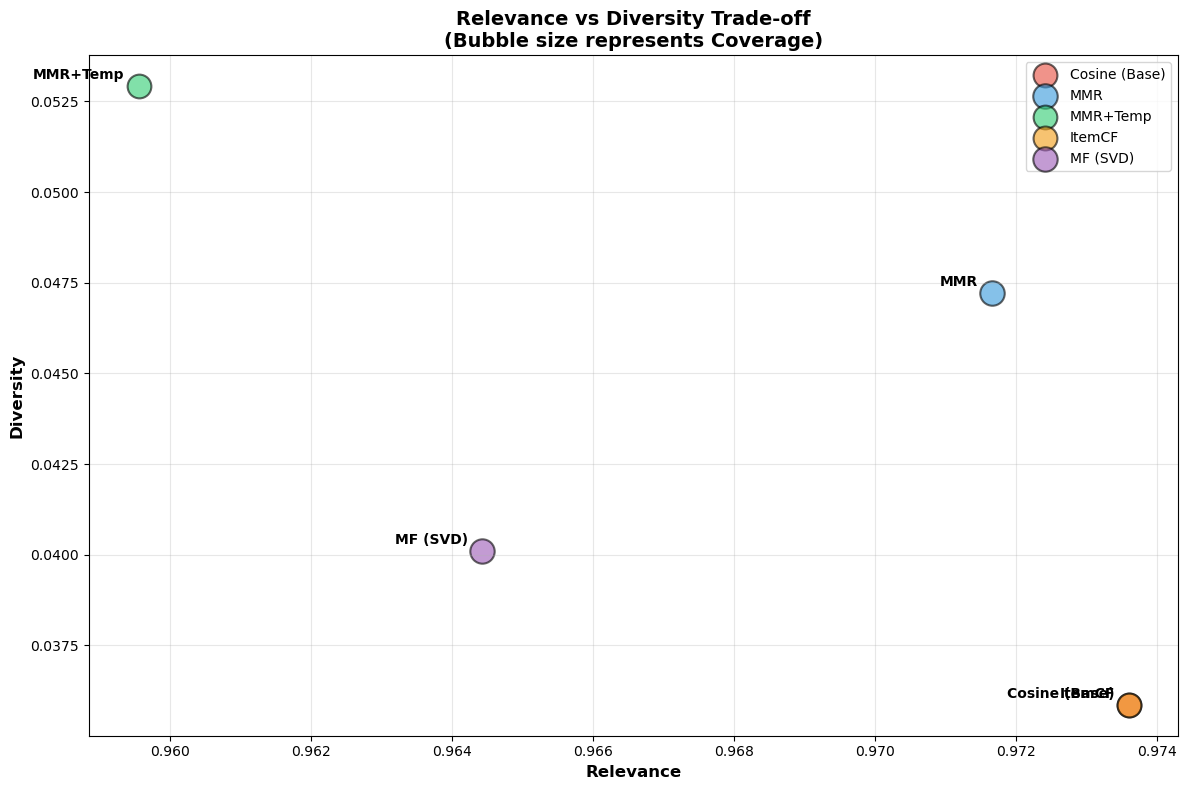

✅ Saved: analysis_06_final_weighted_ranking


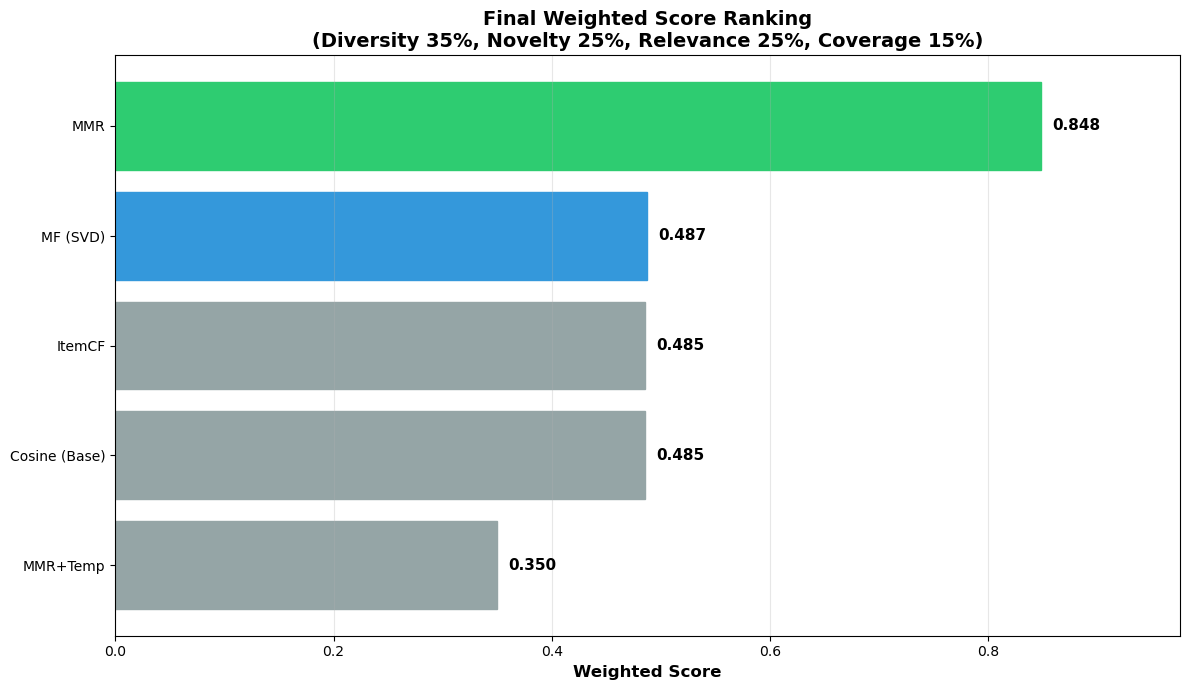


✅ All 6 analysis visualizations saved as individual charts!
   Location: ./outputs\charts
   Files: analysis_01-06 with descriptive names (PNG + JPG)


In [27]:
# Create individual visualization charts for better readability

# 1. Performance Heatmap
fig1 = plt.figure(figsize=(10, 8))
metrics_for_heatmap = results_df.drop('Weighted_Score', axis=1)
im = plt.imshow(metrics_for_heatmap, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.xticks(range(len(metrics_for_heatmap.columns)), metrics_for_heatmap.columns, rotation=45, ha='right', fontsize=11)
plt.yticks(range(len(metrics_for_heatmap.index)), metrics_for_heatmap.index, fontsize=11)
plt.title('Performance Heatmap - All Methods & Metrics', fontweight='bold', fontsize=14, pad=20)
plt.xlabel('Metrics', fontweight='bold', fontsize=12)
plt.ylabel('Methods', fontweight='bold', fontsize=12)

for i in range(len(metrics_for_heatmap.index)):
    for j in range(len(metrics_for_heatmap.columns)):
        plt.text(j, i, f'{metrics_for_heatmap.iloc[i, j]:.3f}',
                ha="center", va="center", color="black", fontsize=10, fontweight='bold')

plt.colorbar(im, label='Score')
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'analysis_01_performance_heatmap_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'analysis_01_performance_heatmap_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: analysis_01_performance_heatmap")
plt.show()

# 2. Grouped Bar Chart Comparison
fig2 = plt.figure(figsize=(14, 7))
x_pos = np.arange(len(metrics_for_heatmap.columns))
width = 0.15
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for i, method in enumerate(metrics_for_heatmap.index):
    offset = (i - 2) * width
    plt.bar(x_pos + offset, metrics_for_heatmap.loc[method], width, 
            label=method, color=colors[i], alpha=0.8)

plt.xlabel('Metrics', fontweight='bold', fontsize=12)
plt.ylabel('Score', fontweight='bold', fontsize=12)
plt.title('Grouped Bar Chart - Method Comparison Across Metrics', fontweight='bold', fontsize=14)
plt.xticks(x_pos, metrics_for_heatmap.columns, fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'analysis_02_grouped_bar_comparison_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'analysis_02_grouped_bar_comparison_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: analysis_02_grouped_bar_comparison")
plt.show()

# 3. Distribution Box Plot
fig3 = plt.figure(figsize=(12, 7))
data_for_box = [metrics_for_heatmap.loc[method].values for method in metrics_for_heatmap.index]
bp = plt.boxplot(data_for_box, labels=metrics_for_heatmap.index, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
plt.ylabel('Score', fontweight='bold', fontsize=12)
plt.title('Score Distribution by Method', fontweight='bold', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right', fontsize=11)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'analysis_03_distribution_boxplot_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'analysis_03_distribution_boxplot_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: analysis_03_distribution_boxplot")
plt.show()

# 4. Improvement vs Baseline
fig4 = plt.figure(figsize=(12, 6))
improvement_data = improvements[['Relevance', 'Diversity', 'Novelty', 'Coverage']].mean(axis=1).sort_values(ascending=True)
bars4 = plt.barh(improvement_data.index, improvement_data.values)
for i, (bar, val) in enumerate(zip(bars4, improvement_data.values)):
    if val >= 0:
        bar.set_color('#2ecc71')
    else:
        bar.set_color('#e74c3c')
    plt.text(val, i, f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right', 
             fontweight='bold', fontsize=11)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Average Improvement (%)', fontweight='bold', fontsize=12)
plt.title('Average Improvement vs Baseline (Cosine)', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'analysis_04_improvement_vs_baseline_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'analysis_04_improvement_vs_baseline_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: analysis_04_improvement_vs_baseline")
plt.show()

# 5. Relevance vs Diversity Trade-off Scatter
fig5 = plt.figure(figsize=(12, 8))
for i, method in enumerate(results_df.index):
    plt.scatter(results_df.loc[method, 'Relevance'], 
               results_df.loc[method, 'Diversity'],
               s=results_df.loc[method, 'Coverage']*800,  # size = coverage
               c=[colors[i]], alpha=0.6, label=method, edgecolors='black', linewidth=1.5)
    plt.annotate(method, 
                (results_df.loc[method, 'Relevance'], results_df.loc[method, 'Diversity']),
                fontsize=10, ha='right', fontweight='bold',
                xytext=(-10, 5), textcoords='offset points')
plt.xlabel('Relevance', fontweight='bold', fontsize=12)
plt.ylabel('Diversity', fontweight='bold', fontsize=12)
plt.title('Relevance vs Diversity Trade-off\n(Bubble size represents Coverage)', 
          fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'analysis_05_relevance_diversity_tradeoff_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'analysis_05_relevance_diversity_tradeoff_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: analysis_05_relevance_diversity_tradeoff")
plt.show()

# 6. Final Weighted Score Ranking
fig6 = plt.figure(figsize=(12, 7))
sorted_scores = results_df['Weighted_Score'].sort_values(ascending=True)
bars6 = plt.barh(sorted_scores.index, sorted_scores.values)

# Color top 2 methods differently
for i, bar in enumerate(bars6):
    if i == len(bars6) - 1:  # Best method
        bar.set_color('#2ecc71')
    elif i == len(bars6) - 2:  # Second best
        bar.set_color('#3498db')
    else:
        bar.set_color('#95a5a6')

for i, (idx, val) in enumerate(sorted_scores.items()):
    plt.text(val + 0.01, i, f'{val:.3f}', va='center', fontweight='bold', fontsize=11)

plt.xlabel('Weighted Score', fontweight='bold', fontsize=12)
plt.title('Final Weighted Score Ranking\n(Diversity 35%, Novelty 25%, Relevance 25%, Coverage 15%)', 
          fontweight='bold', fontsize=14)
plt.xlim(0, max(sorted_scores.values) * 1.15)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

chart_png = os.path.join(CHARTS_DIR, f'analysis_06_final_weighted_ranking_{RUN_TIMESTAMP}.png')
chart_jpg = os.path.join(CHARTS_DIR, f'analysis_06_final_weighted_ranking_{RUN_TIMESTAMP}.jpg')
plt.savefig(chart_png, dpi=300, bbox_inches='tight')
plt.savefig(chart_jpg, dpi=300, bbox_inches='tight', pil_kwargs={'quality': 95})
print(f"✅ Saved: analysis_06_final_weighted_ranking")
plt.show()

print("\n" + "="*80)
print("✅ All 6 analysis visualizations saved as individual charts!")
print(f"   Location: {CHARTS_DIR}")
print("   Files: analysis_01-06 with descriptive names (PNG + JPG)")
print("="*80)

## Export Results to CSV

In [28]:
# Export all results to CSV files for further analysis

# 1. Main results
results_export = results_df.copy()
report_file = os.path.join(REPORTS_DIR, f'recommendation_performance_{RUN_TIMESTAMP}.csv')
results_export.to_csv(report_file)
print(f"✅ Exported main results to: {report_file}")

# 2. Statistical summary
metrics_cols = ['Relevance', 'Diversity', 'Novelty', 'Coverage']
stats_summary = pd.DataFrame({
    'Mean': results_df[metrics_cols].mean(),
    'Std': results_df[metrics_cols].std(),
    'Min': results_df[metrics_cols].min(),
    'Max': results_df[metrics_cols].max(),
    'Range': results_df[metrics_cols].max() - results_df[metrics_cols].min()
})
stats_file = os.path.join(REPORTS_DIR, f'statistical_summary_{RUN_TIMESTAMP}.csv')
stats_summary.to_csv(stats_file)
print(f"✅ Exported statistical summary to: {stats_file}")

# 3. Improvement analysis
baseline = results_df.loc['Cosine (Base)', metrics_cols]
improvements = pd.DataFrame()
for method in results_df.index:
    if method != 'Cosine (Base)':
        improvement = ((results_df.loc[method, metrics_cols] - baseline) / baseline * 100)
        improvements = pd.concat([improvements, improvement.to_frame(method).T])
improvement_file = os.path.join(REPORTS_DIR, f'improvement_analysis_{RUN_TIMESTAMP}.csv')
improvements.to_csv(improvement_file)
print(f"✅ Exported improvement analysis to: {improvement_file}")

# 4. Detailed comparison report
detailed_report = pd.DataFrame({
    'Method': results_df.index,
    'Relevance': results_df['Relevance'].values,
    'Diversity': results_df['Diversity'].values,
    'Novelty': results_df['Novelty'].values,
    'Coverage': results_df['Coverage'].values,
    'Weighted_Score': results_df['Weighted_Score'].values,
    'Rank': range(1, len(results_df) + 1)
})
detailed_report = detailed_report.sort_values('Weighted_Score', ascending=False).reset_index(drop=True)
detailed_report['Rank'] = range(1, len(detailed_report) + 1)
ranking_file = os.path.join(REPORTS_DIR, f'detailed_ranking_{RUN_TIMESTAMP}.csv')
detailed_report.to_csv(ranking_file, index=False)
print(f"✅ Exported detailed ranking to: {ranking_file}")

print(f"\n📊 All reports exported with timestamp: {RUN_TIMESTAMP}")
print(f"   Reports directory: {REPORTS_DIR}")
print(f"   Charts directory: {CHARTS_DIR}")
print(f"   Raw data directory: {RAW_DATA_DIR}")

✅ Exported main results to: ./outputs\reports\recommendation_performance_20251209_195414.csv
✅ Exported statistical summary to: ./outputs\reports\statistical_summary_20251209_195414.csv
✅ Exported improvement analysis to: ./outputs\reports\improvement_analysis_20251209_195414.csv
✅ Exported detailed ranking to: ./outputs\reports\detailed_ranking_20251209_195414.csv

📊 All reports exported with timestamp: 20251209_195414
   Reports directory: ./outputs\reports
   Charts directory: ./outputs\charts
   Raw data directory: ./outputs\raw_data
